# Horizontal ramp with a step
This notbook covers the conformal mapping of a horizontal ramp with a step. The step is centerd along th `y`-axis and of a defined hight ``h``.

## The mapping
The mapping is dervied using Schwartz-Christoffel and is of the from
\begin{equation*}
z = \frac{h}{\pi}\left[ \sqrt{\chi - 1} \sqrt{\chi + 1}  + \ln\left(\chi + \sqrt{\chi - 1} \sqrt{\chi + 1}\right)\right]
\end{equation*}

In [10]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from conformal_mappings.elements import omega_uni_flow
from conformal_mappings.mappings import xi_to_ramp
from conformal_mappings.plotter import contour_flow_net

We define the ramp with the following variable

In [11]:
# Variables
h = 1

# Plot limits
xlim = (-10, 10)
ylim = (-1, h + 1)

The ramp is mapped on to the half-plane, or rather the half plane in the `chi`-plane is mapped onto the ramp in the `z`-plane.

```{warning}
Becuse the mapping is from `chi`to `z`the elements must be defined in the `chi`plane.
```

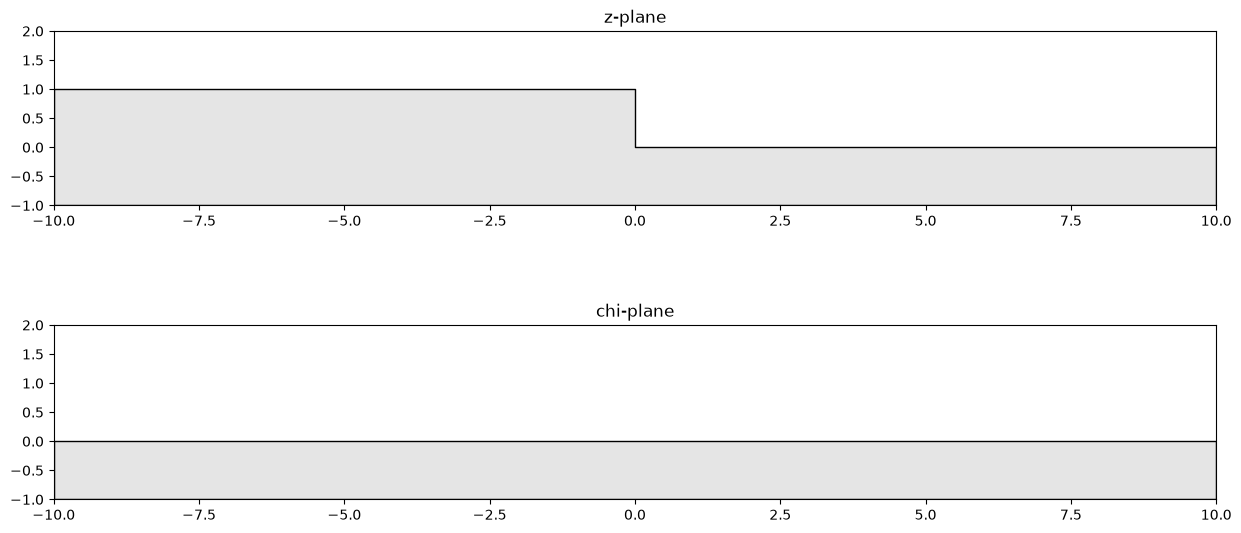

In [26]:
fig, ax = plt.subplots(2,1, figsize=(15, 7))
ax[0].fill_between([xlim[0], 0, 0, xlim[1]], [h, h, 0, 0], y2=-1, facecolor=(.8,.8,.8,.5), edgecolor="k")
ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)
ax[0].set_title("z-plane")
ax[0].set_aspect('equal')

# Chi-plane plot
ax[1].fill_between([xlim[0],xlim[1]], [0, 0], y2=-1, facecolor=(.8,.8,.8,.5), edgecolor="k")
ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)
ax[1].set_title("chi-plane")
ax[1].set_aspect('equal')
plt.show()

## Horizonatal uniform flow
We model horizontal uniform flow by defining unfirom flow parallel to the `x`-axis in the `chi`-plane.

In [13]:
# Varialbes
w = 1 + 0j

# Omega function
omega_func = lambda z: omega_uni_flow(z, w)

We can now plot the solution

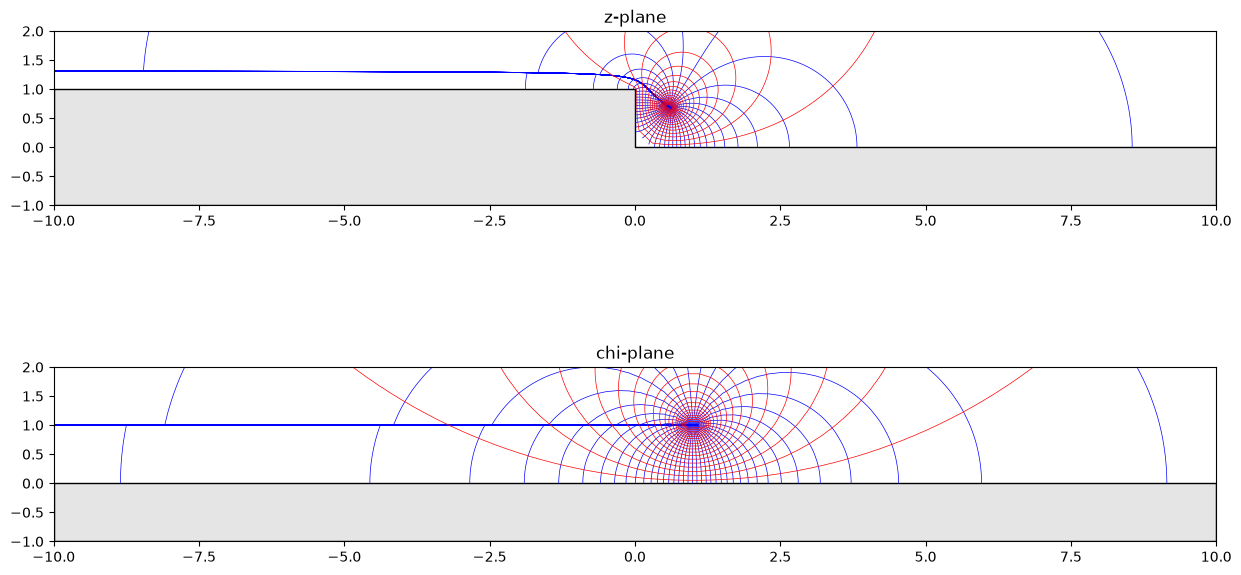

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(15, 7))
contour_flow_net(
    (-40,40),
    (0, h + 5),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_ramp(chi, h),
    ax=ax[0]
)
ax[0].fill_between([xlim[0], 0, 0, xlim[1]], [h, h, 0, 0], y2=-1, facecolor=(.8,.8,.8,.5), edgecolor="k")
ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)
ax[0].set_title("z-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-40,40),
    (0, h + 5),
    flow_func= omega_func,
    levels=50,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].fill_between([xlim[0], xlim[1]], [0, 0], y2=-1, facecolor=(.8,.8,.8,.5), edgecolor="k")
ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)
ax[1].set_title("chi-plane")
ax[1].set_aspect('equal')
plt.show()

## Well close to a coast line
In this example we will use the method of images and place a well close to a coast line shaped as the ramp.

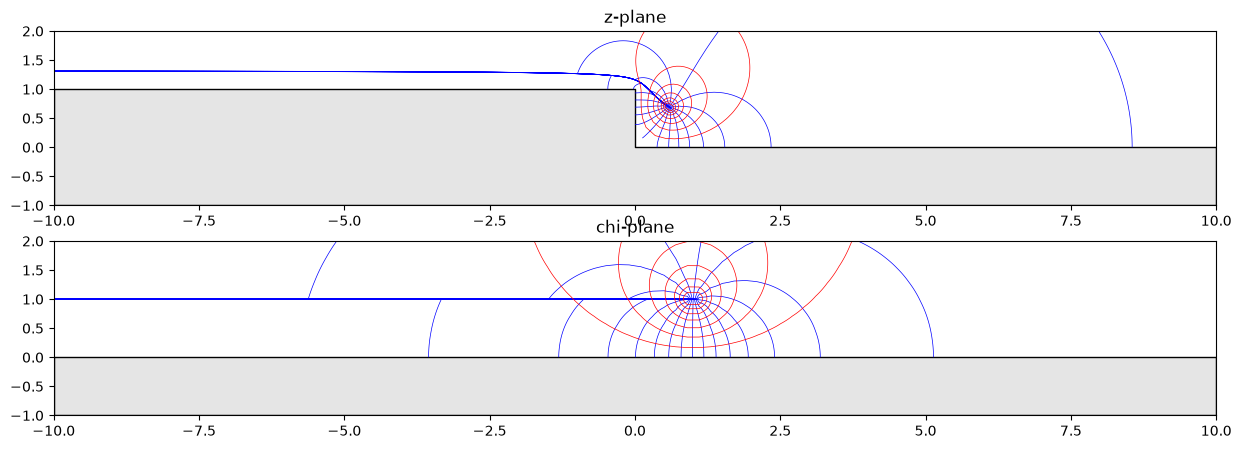

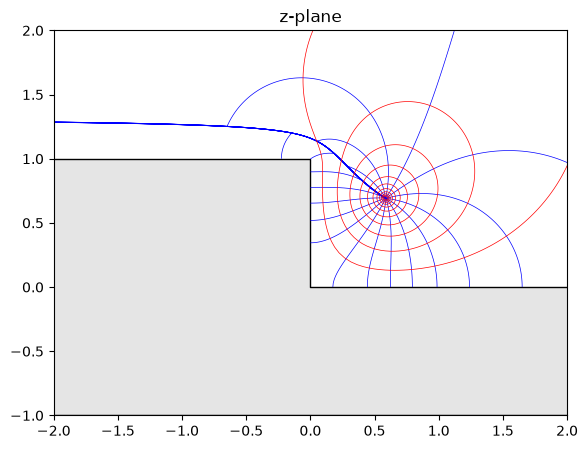

In [ ]:
# Varialbes
from conformal_mappings.elements import omega_well


q = 1
zw = 1 + 1j

# Omega function
omega_func = lambda z: omega_well(z, q, lambda z: z-zw) - omega_well(z, q, lambda z: z-np.conj(zw))

fig, ax = plt.subplots(2,1,figsize=(15, 7))
contour_flow_net(
    (-40,40),
    (0, h + 5),
    flow_func= omega_func,
    levels=20,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_ramp(chi, h),
    ax=ax[0]
)
ax[0].fill_between([xlim[0], 0, 0, xlim[1]], [h, h, 0, 0], y2=-1, facecolor=(.8,.8,.8,.5), edgecolor="k")
ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)
ax[0].set_title("z-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-40,40),
    (0, h + 5),
    flow_func= omega_func,
    levels=20,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)
ax[1].fill_between([xlim[0], xlim[1]], [0, 0], y2=-1, facecolor=(.8,.8,.8,.5), edgecolor="k")
ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)
ax[1].set_title("chi-plane")
ax[1].set_aspect('equal')

fig, ax = plt.subplots(1,1,figsize=(15, 5))
contour_flow_net(
    (-10,10),
    (0, h + 4),
    flow_func= omega_func,
    levels=20,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_ramp(chi, h),
    ax=ax
)
ax.fill_between([xlim[0], 0, 0, xlim[1]], [h, h, 0, 0], y2=-1, facecolor=(.8,.8,.8,.5), edgecolor="k")
ax.set_xlim((-2,2))
ax.set_ylim(ylim)
ax.set_title("z-plane")
ax.set_aspect('equal')

plt.show()

## Impermeable curced boudnary
We can also make the boundary cured by offsetting the constant stream lime separating the images.

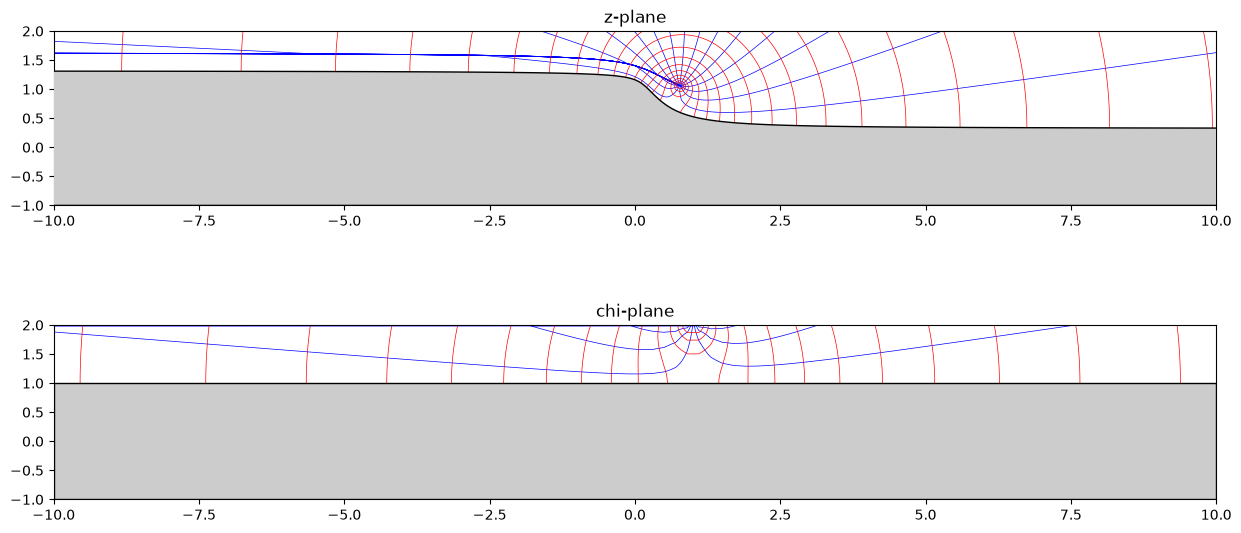

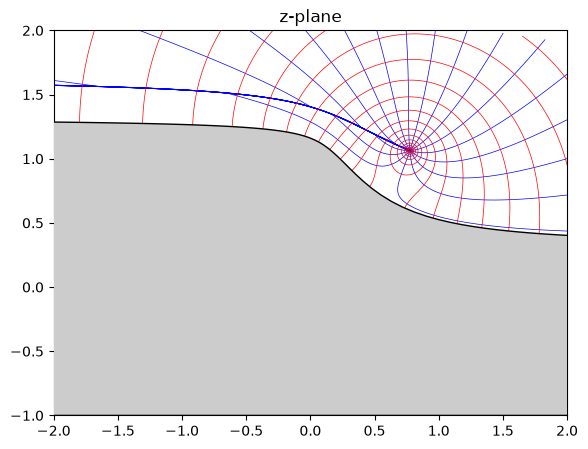

In [34]:
# Varialbes
q = 1
zw = 1 + 2j

# Omega function
omega_func = lambda z: omega_well(z, q, lambda z: z-zw) + omega_well(z, q, lambda z: z-(np.conj(zw)+2j))

fig, ax = plt.subplots(2,1,figsize=(15, 7))
contour_flow_net(
    (-40,40),
    (0, h + 5),
    flow_func= omega_func,
    levels=20,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_ramp(chi, h),
    ax=ax[0]
)
z = xi_to_ramp(np.linspace(-40, 40, 400)+1j, h)
ax[0].fill_between(z.real, z.imag, y2=-1, facecolor=(.8,.8,.8,1), edgecolor="k", zorder=10)
ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)
ax[0].set_title("z-plane")
ax[0].set_aspect('equal')

contour_flow_net(
    (-40,40),
    (0, h + 5),
    flow_func= omega_func,
    levels=20,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=None,
    ax=ax[1]
)

ax[1].fill_between([xlim[0], xlim[1]], [1, 1], y2=-1, facecolor=(.8,.8,.8,1), edgecolor="k", zorder=10)
ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)
ax[1].set_title("chi-plane")
ax[1].set_aspect('equal')

fig, ax = plt.subplots(1,1,figsize=(15, 5))
contour_flow_net(
    (-10,10),
    (0, h + 4),
    flow_func= omega_func,
    levels=20,
    xgrid_points=400,
    ygrid_points=400,
    mapping_func=lambda chi: xi_to_ramp(chi, h),
    ax=ax
)
ax.fill_between(z.real, z.imag, y2=-1, facecolor=(.8,.8,.8,1), edgecolor="k", zorder=10)
ax.set_xlim((-2,2))
ax.set_ylim(ylim)
ax.set_title("z-plane")
ax.set_aspect('equal')

plt.show()